In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/student_performance.csv')  # adjust path if needed

print("Shape:", df.shape)
df.head()

Shape: (1000000, 6)


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [5]:
print(df.info())
print("\n", df.describe())


            student_id  weekly_self_study_hours  attendance_percentage  \
count  1000000.000000           1000000.000000         1000000.000000   
mean    500000.500000                15.029127              84.711046   
std     288675.278932                 6.899431               9.424143   
min          1.000000                 0.000000              50.000000   
25%     250000.750000                10.300000              78.300000   
50%     500000.500000                15.000000              85.000000   
75%     750000.250000                19.700000              91.800000   
max    1000000.000000                40.000000             100.000000   

       class_participation     total_score  
count       1000000.000000  1000000.000000  
mean              5.985203       84.283845  
std               1.956421       15.432969  
min               0.000000        9.400000  
25%               4.700000       73.900000  
50%               6.000000       87.500000  
75%               7.30000

In [6]:
#cleaning of the data
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique grades:", df['grade'].unique())

# If duplicates show up, we'd drop them with 
# df.drop_duplicates(inplace=True).



Unique grades: <ArrowStringArray>
['A', 'B', 'C', 'D', 'F']
Length: 5, dtype: str


In [7]:
print("Grade distribution:")
print(df['grade'].value_counts())

print("\nGrade distribution (%):")
print(df['grade'].value_counts(normalize=True) * 100)

Grade distribution:
grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64

Grade distribution (%):
grade
A    54.8644
B    25.8174
C    14.1980
D     4.4998
F     0.6204
Name: proportion, dtype: float64


In [8]:
# Correlation matrix between numeric columns
numeric_cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                         weekly_self_study_hours  attendance_percentage  \
weekly_self_study_hours                 1.000000              -0.001008   
attendance_percentage                  -0.001008               1.000000   
class_participation                     0.001244              -0.000043   
total_score                             0.812241              -0.001014   

                         class_participation  total_score  
weekly_self_study_hours             0.001244     0.812241  
attendance_percentage              -0.000043    -0.001014  
class_participation                 1.000000     0.000684  
total_score                         0.000684     1.000000  


In [9]:
score_correlation = correlation_matrix['total_score'].sort_values(ascending=False)
print(score_correlation)

total_score                1.000000
weekly_self_study_hours    0.812241
class_participation        0.000684
attendance_percentage     -0.001014
Name: total_score, dtype: float64


In [10]:
print(df.groupby('grade')['total_score'].mean().sort_values(ascending=False))

grade
A    96.042375
B    77.946590
C    63.564524
D    49.380346
F    35.474146
Name: total_score, dtype: float64


In [11]:
grade_summary = df.groupby('grade')[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']].mean()
print(grade_summary)

       weekly_self_study_hours  attendance_percentage  class_participation
grade                                                                     
A                    19.375738              84.710114             5.986642
B                    12.115533              84.696178             5.985690
C                     7.691161              84.726340             5.976975
D                     3.764143              84.723243             5.991766
F                     1.524662              84.973662             5.978337


In [12]:
#Identify at-risk students (numpy z-scores)
scores = df['total_score'].to_numpy()

mean_score = np.mean(scores)
std_score = np.std(scores)

df['z_score'] = (df['total_score'] - mean_score) / std_score

# At-risk: more than 1.5 std deviations below mean
at_risk = df[df['z_score'] < -1.5]
print(f"Number of at-risk students: {len(at_risk)}")
print(at_risk[['student_id', 'total_score', 'attendance_percentage', 'weekly_self_study_hours']].head(10))

Number of at-risk students: 94882
    student_id  total_score  attendance_percentage  weekly_self_study_hours
13          14         60.9                   92.1                      1.6
14          15         52.1                   90.7                      2.9
19          20         57.9                   91.4                      5.1
23          24         58.7                   74.2                      5.0
37          38         50.1                   92.9                      1.3
38          39         56.7                   93.4                      5.7
44          45         55.9                  100.0                      4.7
49          50         51.1                   77.5                      2.7
74          75         47.4                   86.4                      0.0
79          80         54.6                   81.4                      1.1


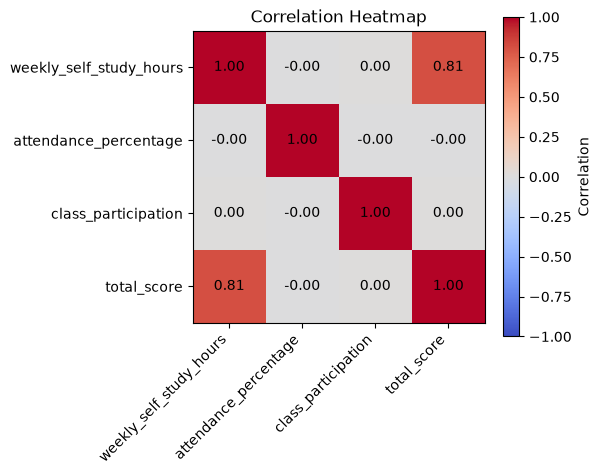

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Heatmap')

# annotate each cell with its value
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{correlation_matrix.iloc[i,j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

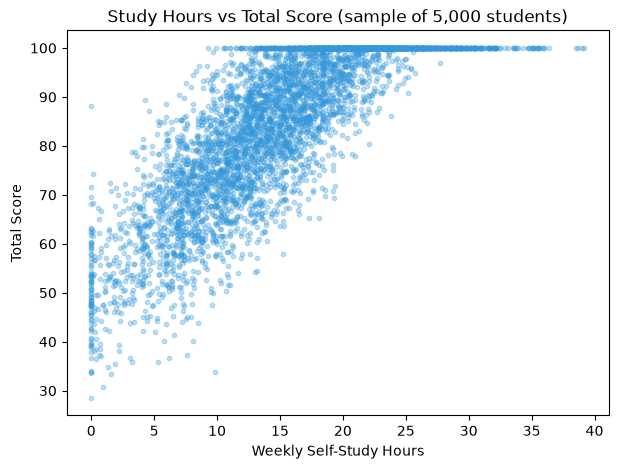

In [14]:
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample['weekly_self_study_hours'], sample['total_score'], alpha=0.3, s=10, color='#3498db')
plt.title('Study Hours vs Total Score (sample of 5,000 students)')
plt.xlabel('Weekly Self-Study Hours')
plt.ylabel('Total Score')
plt.savefig('study_hours_vs_score.png')
plt.show()

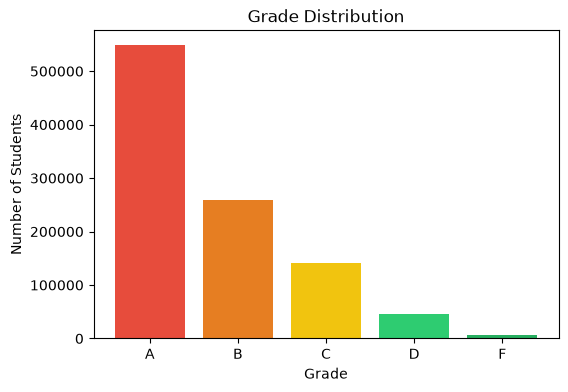

In [15]:
grade_counts = df['grade'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(grade_counts.index, grade_counts.values, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.savefig('grade_distribution.png')
plt.show()


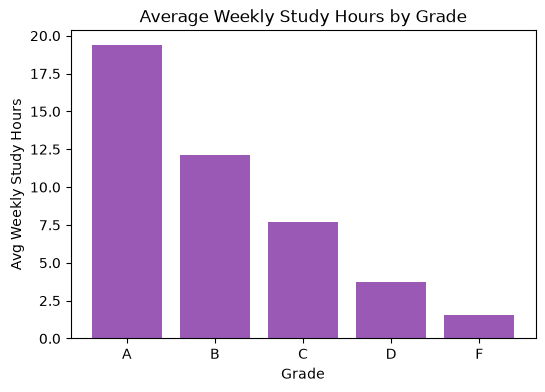

In [16]:
avg_hours_by_grade = df.groupby('grade')['weekly_self_study_hours'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(avg_hours_by_grade.index, avg_hours_by_grade.values, color='#9b59b6')
plt.title('Average Weekly Study Hours by Grade')
plt.xlabel('Grade')
plt.ylabel('Avg Weekly Study Hours')
plt.savefig('avg_hours_by_grade.png')
plt.show()

In [17]:
#At-risk student identification
scores = df['total_score'].to_numpy()

mean_score = np.mean(scores)
std_score = np.std(scores)

df['z_score'] = (df['total_score'] - mean_score) / std_score

# At-risk: more than 1.5 std deviations below mean
at_risk = df[df['z_score'] < -1.5]
print(f"Total students: {len(df)}")
print(f"Number of at-risk students: {len(at_risk)} ({len(at_risk)/len(df)*100:.2f}%)")
print(at_risk[['student_id', 'total_score', 'attendance_percentage', 'weekly_self_study_hours', 'grade']].head(10))


Total students: 1000000
Number of at-risk students: 94882 (9.49%)
    student_id  total_score  attendance_percentage  weekly_self_study_hours  \
13          14         60.9                   92.1                      1.6   
14          15         52.1                   90.7                      2.9   
19          20         57.9                   91.4                      5.1   
23          24         58.7                   74.2                      5.0   
37          38         50.1                   92.9                      1.3   
38          39         56.7                   93.4                      5.7   
44          45         55.9                  100.0                      4.7   
49          50         51.1                   77.5                      2.7   
74          75         47.4                   86.4                      0.0   
79          80         54.6                   81.4                      1.1   

   grade  
13     C  
14     D  
19     C  
23     C  
37     D 

In [18]:
print("At-risk students' average stats:")
print(at_risk[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']].mean())

print("\nOverall average stats (for comparison):")
print(df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']].mean())


At-risk students' average stats:
weekly_self_study_hours     4.680944
attendance_percentage      84.753944
class_participation         5.985812
dtype: float64

Overall average stats (for comparison):
weekly_self_study_hours    15.029127
attendance_percentage      84.711046
class_participation         5.985203
dtype: float64


In [19]:
#Export a summary report

summary = {
    'Total Students': len(df),
    'Average Total Score': round(df['total_score'].mean(), 2),
    'Correlation: Study Hours vs Score': round(correlation_matrix.loc['weekly_self_study_hours', 'total_score'], 3),
    'Correlation: Attendance vs Score': round(correlation_matrix.loc['attendance_percentage', 'total_score'], 3),
    'Correlation: Participation vs Score': round(correlation_matrix.loc['class_participation', 'total_score'], 3),
    'At-Risk Students (z-score < -1.5)': len(at_risk),
    'At-Risk %': round(len(at_risk)/len(df)*100, 2),
    'At-Risk Avg Study Hours': round(at_risk['weekly_self_study_hours'].mean(), 2),
    'Overall Avg Study Hours': round(df['weekly_self_study_hours'].mean(), 2),
    'Grade A %': round((df['grade']=='A').mean()*100, 2),
    'Grade F %': round((df['grade']=='F').mean()*100, 2),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.to_csv('summary_report.csv', index=False)
print(summary_df)


                                 Metric        Value
0                        Total Students  1000000.000
1                   Average Total Score       84.280
2     Correlation: Study Hours vs Score        0.812
3      Correlation: Attendance vs Score       -0.001
4   Correlation: Participation vs Score        0.001
5     At-Risk Students (z-score < -1.5)    94882.000
6                             At-Risk %        9.490
7               At-Risk Avg Study Hours        4.680
8               Overall Avg Study Hours       15.030
9                             Grade A %       54.860
10                            Grade F %        0.620


In [20]:
import os
print(os.getcwd())


C:\Users\PC\student-performance-analyzer


In [21]:
import os
for f in os.listdir():
    print(f)

.ipynb_checkpoints
analyzer.ipynb
avg_hours_by_grade.png
correlation_heatmap.png
grade_distribution.png
student_performance.csv
study_hours_vs_score.png
summary_report.csv


In [22]:
import os
import shutil

# Create folders
os.makedirs('data', exist_ok=True)
os.makedirs('images', exist_ok=True)

# Move CSV into data/
shutil.move('student_performance.csv', 'data/student_performance.csv')

# Move all chart images into images/
for img in ['avg_hours_by_grade.png', 'correlation_heatmap.png', 'grade_distribution.png', 'study_hours_vs_score.png']:
    shutil.move(img, f'images/{img}')

print("Done! New structure:")
for root, dirs, files in os.walk('.'):
    if '.ipynb_checkpoints' in root:
        continue
    for f in files:
        print(os.path.join(root, f))

Done! New structure:
.\analyzer.ipynb
.\summary_report.csv
.\data\student_performance.csv
.\images\avg_hours_by_grade.png
.\images\correlation_heatmap.png
.\images\grade_distribution.png
.\images\study_hours_vs_score.png
